<div style="font-size: 18px; padding: 15px; border: 2px solid #ed8936; background-color: #fffaf0; border-radius: 8px; text-align: center;">
    <strong>Note for Readers:</strong> This notebook contains specialized styling and high-resolution audits.
    <br>
    <a href="https://nbviewer.org/github/jessicak222/Olist-Data-Stabilization-Audit-/blob/main/Olist_Stabilization_Audit.ipynb" style="color: #dd6b20; font-weight: bold;">
    Click here to view the report on NBViewer</a>
    for the best reading experience.
</div>

## **Project Navigation**
* [1. Objective](#objective)
* [2. Data Cleaning](#cleaning)
* [3. Statistical Investigation](#investigation)
* [4. The Stabilization Model](#stabilization)
* [5. Final Audit](#final)
* [Appendix](#appendix)

# **1. Olist Data Stabilization Audit**  <a name='objective'></a>

**Technical Objective:** Neutralizing a Global Price Skew of 7.7 in the Olist dataset to stabilize revenue forecasting.

# **2. Data Quality & Cleaning**  <a name='cleaning'></a>

I performed the initial investigation and cleaning using **SQL** for its robust ability to aggregate and summarize large datasets, then created an **intermediate table** to perform further analysis on. The **Item Summary** table includes information about every item from every order. The query standardizes dates, corrects spelling and translation, and provides clearer context for variables.  
Canceled orders were excluded.  
<br>
Some `product_category_name` fields were empty, which originally resulted in those rows being excluded. Setting the `product_category_name` for those entries to "uncategorized" and applying `LEFT JOIN` on the `translation` dataset allowed the data to be included in future analysis.

```sql
SELECT
  o.order_id,
  i.order_item_id,
  i.price AS item_price,
  i.freight_value,
  DATE(o.order_purchase_timestamp) AS purchase_date,
  COALESCE(p.product_category_name, 'uncategorized') AS category_portuguese,
  REGEXP_REPLACE(
    CASE
      WHEN t.string_field_0 = 'cama_mesa_banho' THEN 'bed_bath_table_linens'
      WHEN t.string_field_0 = 'casa_conforto' THEN 'home_comfort'
      WHEN t.string_field_0 = 'construcao_ferramentas_construcao' THEN 'construction_building_tools'
      WHEN t.string_field_0 = 'construcao_ferramentas_ferramentas' THEN 'construction_tools_hardware'
      ELSE COALESCE(t.string_field_1, 'uncategorized')
    END, r'_[0-9]+$','') AS category_english,
  o.order_status,
  p.product_id,
  c.customer_unique_id
FROM orders AS o  
  JOIN items AS i ON o.order_id = i.order_id
  JOIN products AS p ON i.product_id = p.product_id
  LEFT JOIN translation AS t ON p.product_category_name = t.string_field_0
  JOIN customers AS c ON c.customer_id = o.customer_id
WHERE o.order_status <> 'canceled'
ORDER BY o.order_id, i.order_item_id
```

For a deeper look into my investigation and cleaning process using SQL queries, view Appendix &sect;A2

# **3. Statistical Investigation** <a name='investigation'></a>


The **Average Order Value** (AOV) is a key metric in determining customer spending behavior. It is calculated by dividing the total revenue by the number of orders in a specified time period.  

$$AOV = \frac{\sum \text{Total Revenue}}{\text{Total Number of Orders}}$$
<br>
The source data spans 24 months, however there are few entries in the beginning months, which may not be a true representation of order activity. For this reason, orders placed in 2016 were excluded.  


### **Median versus Mean AOV**  

I calculated the AOV both the traditional way, using **Mean**, and using the **Median** payment value. The 2017 and 2018 data both show a **positive skew >50%**, indicating that high-value transactions are significantly inflating the average revenue per order. Because of this, the Median is a more reliable indicator of typical customer behavior than the Mean.



In [44]:
display(aov_by_year)

year,total_orders,total_revenue,aov_median,aov_mean,skew_pct
2017,44375,"$7,091,941.15",$103.55,$159.82,54.34%
2018,53531,"$8,594,694.38",$106.87,$160.56,50.23%


<div style="color:#333;">
    <h4>The following code block executes the aggregation of the data and calculation of the variables.</h4>
</div>  

Note: The data was aggregated by order and the first available timestamp was assigned as the definitive purchase date for each unique order ID.

In [43]:
# Re-loading for context/reference
import pandas as pd
item_summary = pd.read_csv('/content/Item Summary v3.csv')
payments = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_order_payments_dataset.csv')

### Analysis
# 1. Group by order_id
# 2. Group and Merge the raw payments DataFrame
# 3. Replace NULLs with 0
# 4. Assign date-time variables for filtering
aov_table = (item_summary.copy()
            .groupby('order_id')
            .agg({'purchase_date': 'first'})
            .reset_index()
            .merge(payments
                   .groupby('order_id')
                   .agg(total_payment = ('payment_value', 'sum')),
                   on='order_id',
                   how='left')
            .fillna({'total_payment': 0})
            .assign(purchase_date = lambda x: pd.to_datetime(x['purchase_date']),
                    year = lambda x: x['purchase_date'].dt.year,
                    month_num = lambda x: x['purchase_date'].dt.month,
                    month = lambda x: x['purchase_date'].dt.month_name())
            .query("year != 2016")
            .sort_values(by=['year', 'month_num'])
)
# 5. Group by Year
# 6. Calculate Mean, Median, and Skew
median_mean = (aov_table.copy()
              .groupby('year')
              .agg(total_orders = ('order_id', 'count'),
                   total_revenue = ('total_payment', 'sum'),
                   aov_median = ('total_payment', 'median') )
              .reset_index()
              .assign(aov_mean = lambda x: x['total_revenue']/x['total_orders'],
                      skew_pct = lambda x: (x['aov_mean'] - x['aov_median'])/x['aov_median'] *100)
)
# 7. Apply formatting to the table
aov_by_year = (median_mean.style
              .pipe(apply_github_style, 'Mean vs. Median AOV by Year')
              .format({'total_revenue': '${:,.2f}', 'aov_median': '${:,.2f}', 'aov_mean': '${:,.2f}', 'skew_pct': '{:.2f}%'})
              .hide(axis='index')
)

### **An Analysis of High-Value Payments**

A statistical analysis of payment data revealed many "outliers" that translated to very high payment values. However, the presence of statistical outliers does not automatically mean the data is "bad" nor necessitate the removal of those data points. Reasons for high payment values include:  
1. **High-Value Categories:** Premium items (e.g., computers, electronics) that are naturally priced higher.
2. **Multi-Item Orders:** In general, orders that include multiple items are likely to have higher payment values than orders in which a single item was purchased.
3. **Anomalous Data:** Single items in low-cost categories (e.g., linens) priced at extreme multiples of their category average, likely representing data entry errors or highly specialized product variants.  

While order-level payments reached \\$14,000 due to multi-item baskets, a granular audit revealed individual item prices peaked at \\$7,000, still representing a 7,700% deviation from the median.  

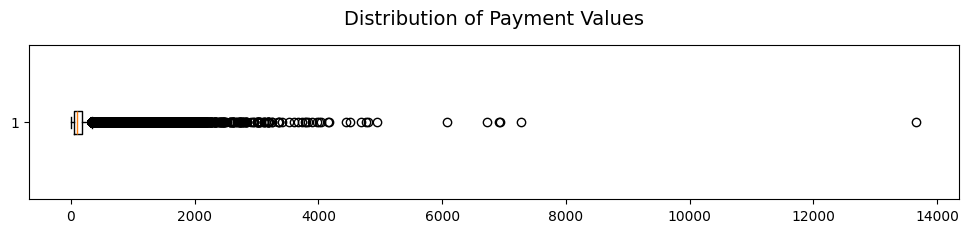

# **4. The Stabilization Model**  <a name='stabilization'></a>

## **Approach to Data Integrity**  

To validate the data and ensure that the final insights accurately reflected the "typical" customer experience, I implemented **Category-Based Thresholds**. Rather than use a blanket filter on the entire dataset, I calculated outlier thresholds (**Q3 + 1.5 x IQR**) for each individual **product category**. These thresholds served as a benchmark and allowed naturally high-priced items to remain in the group while flagging items with suspicious pricing.  

To identify which products were driving order-level anomalies, I performed an audit at the **individual item** level by comparing the total cost of each item (price + freight) to its corresponding category limit.  
#### **Relative Scale**  
I chose to calculate the percent difference for these outliers rather than relying on raw dollar amounts. Comparing raw numbers often lacks context; for example, a \\$50 overage is a minor variance on a \\$1,000 computer, but it represents a drastic pricing variation on a \\$10 towel. Using percentages provided a better way to view the **scale of the variance** and allowed me to highlight the most extreme differences from the category norm.  

#### **Impact on Key Metrics**  
Seeing items priced at 200-300% or more above the statistical threshold confirmed that these were not just "premium" versions of products, but true outliers. These results further supported my decision to use the Median payment value instead of the Mean when calculating AOV.

In [26]:
# Re-loading for context/reference
import pandas as pd
item_summary = pd.read_csv('/content/Item Summary v3.csv')
import seaborn as sns

# 1. Calculate Upper Limit per Category
item_cat_box = (item_summary.copy()
                .assign(item_cost = lambda x: x['item_price'] + x['freight_value'])
                .groupby('category_english')
                .agg(q1 = ('item_cost', lambda x: x.quantile(0.25)),
                     q3 = ('item_cost', lambda x: x.quantile(0.75)) )
                .assign(iqr = lambda x: x['q3'] - x['q1'],
                        upper_limit = lambda x: x['q3'] + 1.5*x['iqr'])
                .reset_index()
                )
# 2. Determine Outliers based on Upper Limit
item_cat_pct = (item_summary
                .merge(item_cat_box[['category_english', 'upper_limit']], on='category_english')
                .assign(item_cost = lambda x: x['item_price'] + x['freight_value'],
                        is_outlier = lambda x: x['item_cost'] > x['upper_limit'],
                        pct_difference = lambda x: ((x['item_cost'] - x['upper_limit']) / x['upper_limit'])*100)
                )

# 3. Display Outliers
display(item_cat_pct[['order_id', 'category_english', 'item_cost', 'upper_limit', 'is_outlier', 'pct_difference']]
 [item_cat_pct['is_outlier'] == True].head(10)
        .style.pipe(apply_github_style, 'Item-level Outlier Audit: Identification of High-Variance Pricing')
        .hide(axis='index')
        .format({'item_cost': '${:,.2f}', 'upper_limit': '${:,.2f}', 'pct_difference': '{:,.2f}%'})
        .background_gradient(cmap='Oranges', subset=['pct_difference'])
)
display(HTML(f"""
<div style="font-size: 18px; color: #333; display: flex; justify-content: center; pad=10px">
  <i>Note: Orange gradient indicates severity of deviation from category limits<i> </div>
  """))

order_id,category_english,item_cost,upper_limit,is_outlier,pct_difference
00018f77f2f0320c557190d7a144bdd3,pet_shop,$259.83,$258.43,True,0.54%
000576fe39319847cbb9d288c5617fa6,garden_tools,$880.75,$236.47,True,272.46%
0009c9a17f916a706d71784483a5d643,consoles_games,$650.34,$317.25,True,104.99%
0017afd5076e074a48f1f1a4c7bac9c5,computers_accessories,$853.39,$335.39,True,154.45%
0025c5d1a8ca53a240ec2634bb4492ea,sports_leisure,$419.39,$293.85,True,42.72%
002691433f09002ac9ca0c4e8dbb8ead,telephony,$120.43,$109.60,True,9.88%
00275bce676303c3bfd7292aefdfa223,telephony,$293.36,$109.60,True,167.65%
0029c5db35ef291ce99d1262012e7daa,health_beauty,$514.37,$304.62,True,68.85%
002f16b7bc4530031b7d90f791b12d8a,furniture_decor,$284.13,$229.85,True,23.62%
003423b755b562962a6225a8de40d12e,garden_tools,$261.33,$236.47,True,10.51%


## **Cross-Table Validation**

To neutralize the outliers and ensure that extreme pricing variations did not unfairly inflate revenue figures, my approach was to "cap" extreme prices to a reasonable value and minimize the "noise" created by anomalous data.

Before applying outlier caps, I performed a **cross-table validation** to ensure the **total payment** per order aligned with the **calculated cost** (price + freight). While minor floating-point discrepancies existed at the decimal level, variances were found to be statistically insignificant (Correlation **R = 0.99**), likely stemming from payment installments or voucher usage. Consequently, I moved forward with the **bottom-up capping** approach, using the **sum of capped item costs as the reliable baseline for order revenue**.   

<div style="color:#333;">
    <h4>By <b>capping costs at the item level</b>, I was able to preserve naturally higher prices of premium items, which have a valid impact on revenue, while reducing the impact of unreasonably or inaccurately priced items.</h4>
</div>  

## **Winsorization**

To reduce the impact of extreme outliers, a conservative **category-specific cap** (3 x IQR) was applied using a process called **Winsorization**. This method capped extreme price variances, such as a linen item priced 300% above its category norm, down to a statistically reasonable maximum, while **preserving the legitimate impact** of high-value electronics and luxury goods.  

#### **Data Processing Strategy**  
The raw dataset contains 610 entries without an assigned product category, approximately 2% of total products. To avoid biased capping without specific category benchmarks, a **Global Threshold** was calculated using 3x the Interquartile Range of the entire product catalog. This allowed these mystery entries to remain in the dataset for volume tracking while ensuring they did not introduce unverified price volatility into the revenue model.  

<div style="color:#333;">
  <h4><b>Categorized </b> and <b>Uncategorized </b> items were split into two processing streams, then <b>recombined </b> to create one neutralized dataset.</h4>
</div>

In [6]:
# Re-loading for context/reference
import pandas as pd
import numpy as np
item_summary = pd.read_csv('/content/Item Summary v3.csv')

### Phase 1: Categorized Items
# 1.1 Calculate the category limits
cat_limits = (item_summary[item_summary['category_english'] != 'uncategorized'].copy()
             .assign(item_cost = lambda x: x['item_price'] + x['freight_value'])
             .groupby('category_english')
             .agg(q1 = ('item_cost', lambda x: x.quantile(0.25)),
                  q3 = ('item_cost', lambda x: x.quantile(0.75)) )
             .assign(iqr = lambda x: x['q3'] - x['q1'],
                     cat_limit = lambda x: x['q3'] + 3*x['iqr'] )
             .reset_index()
)
# 1.2 Recombine the category limits with the DataFrame
cat_items = (item_summary[item_summary['category_english'] != 'uncategorized'].copy()
             .assign(item_cost = lambda x: x['item_price'] + x['freight_value'])
             .reset_index()
             .merge(cat_limits[['category_english', 'cat_limit']], on='category_english', how='left')
)
# 1.3 Winsorize - Apply Limits
cat_items['capped_cost'] = np.where(cat_items['item_cost'] > cat_items['cat_limit'],
                                    cat_items['cat_limit'],
                                    cat_items['item_cost'] )

### Phase 2: Uncategorized Items
# 2.1 Calculate the upper limit
item_cost = item_summary['item_price'] + item_summary['freight_value']
q1 = item_cost.quantile(0.25)
q3 = item_cost.quantile(0.75)
iqr = q3 - q1
global_limit = q3 + (3 * iqr)

# 2.2 Winsorize - Apply Limit
# to the "uncategorized" category only
uncat_items = (item_summary[item_summary['category_english'] == 'uncategorized'].copy()
               .assign(item_cost = lambda x: x['item_price'] + x['freight_value'],
                       capped_cost = lambda x: x['item_cost'].clip(upper=global_limit))
               .reset_index()
)

### Phase 3: Recombine the Categorized and Uncategorized items
## into one table with capped values
item_summary_capped = pd.concat([cat_items, uncat_items], ignore_index=True).drop(columns=['cat_limit'])
display(item_summary_capped[['order_id', 'category_english', 'capped_cost']].copy()
        .head()
        .style
        .pipe(apply_github_style, 'Snapshot: Stabilized Item Summary Table')
        .format({'capped_cost': '${:,.2f}'})
        .hide(axis='index')
)

order_id,category_english,capped_cost
00010242fe8c5a6d1ba2dd792cb16214,cool_stuff,$72.19
00018f77f2f0320c557190d7a144bdd3,pet_shop,$259.83
000229ec398224ef6ca0657da4fc703e,furniture_decor,$216.87
00024acbcdf0a6daa1e931b038114c75,perfumery,$25.78
00042b26cf59d7ce69dfabb4e55b4fd9,garden_tools,$218.04


# **5. Final Audit**  <a name='final'></a>

<div style="color:#333;">
    <h3 style="margin-top:0;">Audit Impact: Revenue Neutralization</h3>
    <p style="font-size: 18px">
    The neutralization of outliers stabilized <b>$1.3M in revenue noise</b>,
    successfully reducing the Global Price Skew from <b>7.7 to 4.4</b>.</p>
</div>

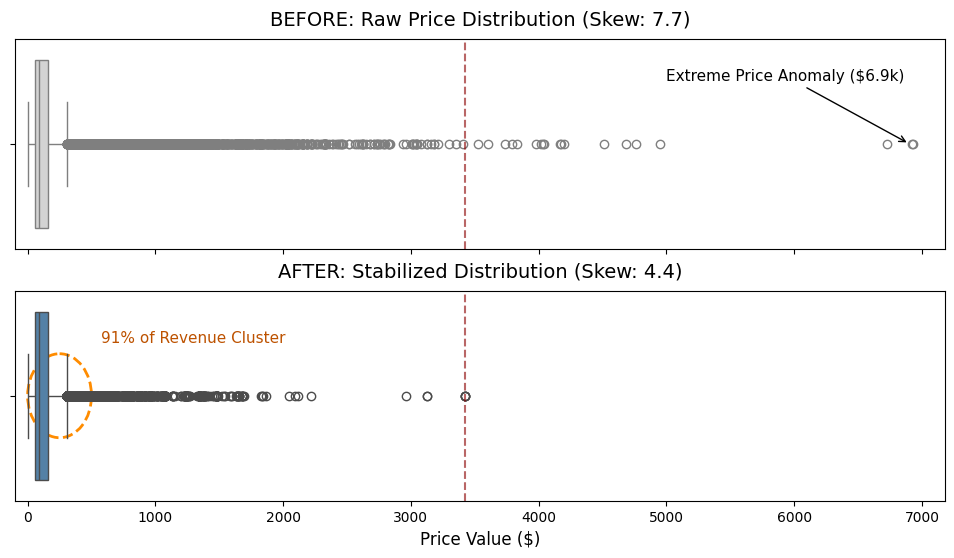

In [59]:
display(boxplots)

The comparison between **raw and capped price values** illustrates a massive **range compression of 50%**, where extreme anomalies (reaching 77x the median) were successfully neutralized. This ensures that the primary data cluster (circled) now dictates the direction of the analysis rather than individual anomalies.

### **Global Distribution Audit**  
#### Comparison of Global Item Metrics (Before vs. After Stabilization):
- **Variance Control:** Standard Deviation reduced by 35% (190 $\to$ 123), indicating a more consistent dataset.
- **Skew Correction:** Global Skewness dropped from 7.7 to 4.4, moving the distribution closer to a normalized state.
- **Reliability:** Successfully preserved 91% of revenue, retaining nearly all organic high-value transaction data.

In [41]:
display(audit_table)

,mean,median,std,skew,max
item_cost,$140.38,$92.30,189.7,7.71,"$6,929.31"
capped_cost,$128.12,$92.30,123.4,4.43,"$3,420.12"


## **Conclusion**  
The dataset is now Forecasting-Ready. By neutralizing outliers at the item-level grain, we have protected the integrity of Olist's financial reporting while retaining the organic high-value signals necessary for growth modeling.

Through a multi-stage stabilization process utilizing **Category-Specific Winsorization**, we effectively neutralized the impact of transactions reaching 77x the median price without deleting valuable high-margin data. The resulting dataset now exhibits a more normalized distribution, allowing leadership to trust revenue trend metrics for the 2019 fiscal year and beyond.

------
# **Appendix** <a name='appendix'></a>

## A1. Libraries and Datasets


In [1]:
# Connect to Kaggle
!pip install --upgrade kagglehub -q
import kagglehub
path = kagglehub.dataset_download("olistbr/brazilian-ecommerce");

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.


In [2]:
# Load libraries
import pandas as pd
from IPython.display import display, Markdown, HTML
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Copy files from Drive
!cp '/content/drive/My Drive/Data Analysis/Olist Project/'*.csv /content/

Mounted at /content/drive


In [ ]:
# Source files
items = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_order_items_dataset.csv')
payments = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_order_payments_dataset.csv')
orders = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_orders_dataset.csv')
products = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_products_dataset.csv')
translation = pd.read_csv('/kaggle/input/brazilian-ecommerce/product_category_name_translation.csv')

In [4]:
# Intermediate tables
customer_summary = pd.read_csv('/content/Customer Summary.csv')
item_summary = pd.read_csv('/content/Item Summary v3.csv')

## A2. Data Cleaning with SQL

### Check for Duplicates

The unique identifier in each dataset was used to check for duplicate entries, which would check for true duplicates and not just entries that happened to contain the same value of one or more variables. Fortunately, there were no duplicate entries in any of the data.    
<br>
A table showing which identifier was used and the number of duplicate entries found can be seen below.   

| Table       | Variable        | Num Duplicates |
| ----------- | --------------- | :----: |
| orders      | order_id    | 0 |
| customers   | customer_id | 0 |
| items       | id[^1]      | 0 |  
| payments    | id[^2]      | 0 |  
| products    | product_id  | 0 |  

<br>
[^1]: To get a unique identifier in the `items` table, the `CONCAT` function was used to combine `order_id` and `order_item_id` to form the new variable `id`.<br>  
[^2]: To get a unique identifier in the `payments` table, the `CONCAT` function was used to combine `order_id` and `payment_sequential` to form the new variable `id`.  

### Check for NULLs

The `.info()` function already alerted me to datasets with NULL entries, such as the `orders` dataset, and I used SQL queries to investigate these further. One variable in each source table, deemed to be most vital to the overall dataset, was inspected.  
<br>
For example, when testing the `orders` dataset, the additional variable checked was `order_approved_at`, since it was the least explainable when empty. It is reasonable that there would be no data for `order_delivered_customer_date` if the `order_status` shows "shipped", but it is less reasonable that an order showing "delivered" would be empty under `order_approved_at`. Some datasets revealed NULL entries for variables that were not prioritized, which are discussed below.  

| Source File | NULLs |
| ----------- | :----:|
| orders      | 160 |
| customers   | 0 |
| items       | 0 |  
| payments    | 0 |  
| products    | 610 |

**Note on Data Contraints**

Further inspection of the `orders` dataset showed that most NULL entries correspond to canceled orders, where a timestamp would not be expected. Orders with a status of "invoiced" or "delivered" and missing timestamps may indicate data inconsistencies. For the purpose of this case study, orders missing a timestamp in any given column were assumed to be the result of data entry error and were kept for the analysis of revenue and volume.  
<br>
The `products` dataset also contains many NULLs across multiple variables. Looking at a snapshot of the data, the blank information relates to the product category and other physical features, which would not affect an analysis on sales data.

## Duplicates and NULLs

*Sample SQL query using the `orders` dataset and the variable `order_id`.*
``` sql
SELECT *
FROM orders
WHERE order_id IN (
    SELECT order_id
    FROM orders
    GROUP BY order_id
    HAVING COUNT(order_id) > 1
    )
ORDER BY order_id
```
<br>  

Below is an example of the SQL query used to find NULL entries, along with a table showing how many empty entries were found in each dataset. Some datasets revealed NULL entries for variables that were not prioritized, which are discussed below.

```sql
SELECT *
FROM products
WHERE product_id IS NULL
  OR product_category_name IS NULL
ORDER BY product_id
```

### Additional Analysis  

Additional investigations were done across all datasets. A few notable highlights include:

- The `orders` table contains 8 distinct values under `order_status` and entries are consistently formatted, allowing the data to be grouped accurately.
- Zip code prefixes in the `customers` and `geolocation` tables vary between four or five characters. In Brazil, zip codes contain eight digits and are typically formatted as XXXXX-XXX. The shorter values were confirmed to be unique values and not partial duplicates, possibly resulting from different truncation methods. Since the values mapped correctly to their regions and geographic coordinates, the mismatch in length did not impact the overall analysis.
- City names listed in the `geolocation` table are not consistently spelled. Some names contain letters with special characters (such as "sáo paulo") or are written as one word (such as "saopaulo"), which caused the same city to be listed more than once when `DISTINCT` values were specified. To sidestep this issue, the city and state names on the `customers` table were used instead, since their spellings are consistent.



## A3. Order-Level Outlier Analysis

Prior to identifying outliers at the item-level, an **order-level** analysis was conducted to expose orders that contributed most to the inflation of the average payment value. Before calculating category thresholds, I performed a **Main Category Assignment** for each unique order. Since an order can contain multiple items, I mapped the entire transaction to its **most occurring category** to ensure that each order was associated with exactly one product category. I then grouped and merged the `payments` DataFrame to compare the *total payment* for each order against the *category threshold*. This allowed for a precise comparison between the **Actual Payment Value** of each order and the **Calculated Upper Limit** for that specific product type.

In [15]:
# Re-loading for context/reference
import pandas as pd
payments = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_order_payments_dataset.csv')
item_summary = pd.read_csv('/content/Item Summary v3.csv')

# 1. Calculate Upper Limit per Category
item_cat_box = (item_summary.copy()
            .assign(item_cost = lambda x: x['item_price'] + x['freight_value'])
            .groupby('category_english')
            .agg(q1 = ('item_cost', lambda x: x.quantile(0.25)),
                 q3 = ('item_cost', lambda x: x.quantile(0.75)) )
            .assign(iqr = lambda x: x['q3'] - x['q1'],
                    upper_limit = lambda x: x['q3'] + 1.5*x['iqr'])
            .reset_index()
          )

# 2. Determine Outliers
## Group working table by Order
## Perform Main Category Assignment
## Group and Merge the raw Payments DataFrame
## Recombine the calculated Upper Limit from above
item_cat_limits = (item_summary.copy()
              .groupby('order_id')
              .agg(num_items = ('order_item_id', 'count'),
                   main_category = ('category_english', lambda x: x.value_counts().index[0]) )
              .reset_index()
              .merge(payments.groupby('order_id')
                     .agg(total_payment = ('payment_value', 'sum')),
                      on='order_id',
                      how='left')
              .fillna({'total_payment': 0})
              .merge(item_cat_box[['category_english', 'upper_limit']],
                     left_on='main_category',
                     right_on='category_english')
              .assign(order_limit = lambda x: x['num_items'] * x['upper_limit'],
                      difference = lambda x: x['total_payment'] - x['order_limit'],
                      is_outlier = lambda x: x['total_payment'] > x['order_limit'],
                      pct_difference = lambda x: ((x['total_payment'] - x['upper_limit']) / x['upper_limit'])*100)
              .drop(columns=['category_english', 'upper_limit'])
              )

# 3. Display Results
display(item_cat_limits
        .drop(columns=['difference']).head(10)
        .style.pipe(apply_github_style,'Order-Level Outlier Analysis')
        .format({'total_payment': '${:,.2f}', 'order_limit': '${:,.2f}', 'pct_difference': '{:.2f}%'})
        .hide(axis='index')
)

order_id,num_items,main_category,total_payment,order_limit,is_outlier,pct_difference
00010242fe8c5a6d1ba2dd792cb16214,1,cool_stuff,$72.19,$424.06,False,-82.98%
00018f77f2f0320c557190d7a144bdd3,1,pet_shop,$259.83,$258.43,True,0.54%
000229ec398224ef6ca0657da4fc703e,1,furniture_decor,$216.87,$229.85,False,-5.65%
00024acbcdf0a6daa1e931b038114c75,1,perfumery,$25.78,$328.64,False,-92.16%
00042b26cf59d7ce69dfabb4e55b4fd9,1,garden_tools,$218.04,$236.47,False,-7.79%
00048cc3ae777c65dbb7d2a0634bc1ea,1,housewares,$34.59,$272.20,False,-87.29%
00054e8431b9d7675808bcb819fb4a32,1,telephony,$31.75,$109.60,False,-71.03%
000576fe39319847cbb9d288c5617fa6,1,garden_tools,$880.75,$236.47,True,272.46%
0005a1a1728c9d785b8e2b08b904576c,1,health_beauty,$157.60,$304.62,False,-48.26%
0005f50442cb953dcd1d21e1fb923495,1,books_technical,$65.39,$185.46,False,-64.74%


## A4. Cross-table Price Validation

#### Comparing **Actual Payment** against **Calculated Cost** to verify that calculating spending behavior using the capped values is statistically sound.

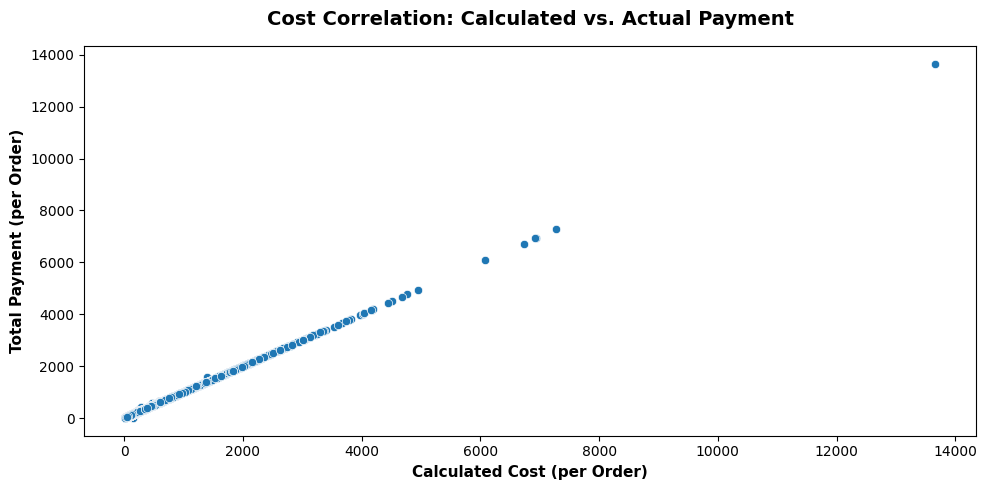

In [22]:
# Re-loading for context/reference
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
payments = pd.read_csv('/kaggle/input/brazilian-ecommerce/olist_order_payments_dataset.csv')
item_summary = pd.read_csv('/content/Item Summary v3.csv')

### Analysis
# 1. Calculate cost per item (price + freight)
# 2. Group by order
# 3. Calculate total payment per order
# 4. Merge payments dataset
calc_costs = (item_summary.copy()
              .assign(calc_cost = lambda x: x['item_price'] + x['freight_value'])
              .groupby('order_id')
              .agg(calc_cost = ('calc_cost', 'sum'))
              .reset_index()
              .merge(payments.groupby('order_id')
                    .agg(total_payment = ('payment_value', 'sum')),
                    on='order_id',
                    how='left')
              .fillna({'total_payment': 0})
)

# Display chart
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(data=calc_costs, x='calc_cost', y='total_payment', ax=ax)

apply_plot_style(ax,
                 title="Cost Correlation: Calculated vs. Actual Payment",
                 xlabel="Calculated Cost (per Order)",
                 ylabel="Total Payment (per Order)")
plt.show()

## A5. Styling & Code Inputs

In [5]:
# Define a master table style
def apply_github_style(styler, title):
    return (styler
        .set_caption(title)
        # 1. Force Caption to the top and center it
        .set_table_styles([
            {'selector': '', 'props': [
                ('margin-left', 'auto'), ('margin-right', 'auto')
            ]},
            {'selector': 'caption', 'props': [
                ('caption-side', 'top'),
                ('text-align', 'center'),
                ('font-size', '16pt'),
                ('font-weight', 'bold'),
                ('padding', '10px'),
                ('color', '#333')
            ]},
            # 2. Format Headers specifically
            {'selector': 'th', 'props': [
                ('background-color', '#f8f9fa'),
                ('color', '#2c3e50'),
                ('font-size', '12pt'),
                ('text-align', 'center'),
                ('border', '1px solid #dee2e6')
            ]}
        ])
        # 3. Format Body Cells
        .set_properties(**{
            'font-size': '11pt',
            'border': '1px solid #dee2e6',
            'text-align': 'center'
        })
    )

In [58]:
# Defining the Before and After boxplots
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches

# 1. Setup the figure
def generate_boxplots():
  fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(12, 6), sharex=True)
# 2. Define the plot limit based on the raw data's max
  upper_bound = item_summary_capped['item_cost'].max() + 250
# 3. Plot the 'BEFORE' (Raw Data)
  sns.boxplot(x='item_cost', data=item_summary_capped, color='lightgray', ax=ax1)
  ax1.set_title('BEFORE: Raw Price Distribution (Skew: 7.7)', fontsize=14, fontweight=530, pad=10)
  ax1.set_xlabel('') # Hide label on top plot for cleanliness
  # Arrow annotation
  ax1.annotate('Extreme Price Anomaly ($6.9k)', xy=(6900, 0), xytext=(5000, -0.3),
             arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=11, fontweight=530)
# 4. Plot the 'AFTER' (Clean/Capped Data)
  sns.boxplot(x='capped_cost', data=item_summary_capped, color='steelblue', ax=ax2)
  ax2.set_title('AFTER: Stabilized Distribution (Skew: 4.4)', fontsize=14, fontweight=530, pad=10)
  ax2.set_xlabel('Price Value ($)', fontsize=12)
  # Circle annotation
  circle = patches.Ellipse((250, 0), width=500, height=0.4, color='darkorange', fill=False, linewidth=2, linestyle='--')
  ax2.add_patch(circle)
  ax2.text(575, -0.25, "91% of Revenue Cluster", color='#bd5200', fontsize=11, fontweight=545)
# 5. Force both to the same scale
  ax1.set_xlim(-100, upper_bound)
  ax2.set_xlim(-100, upper_bound)
# 6. Add the "Stabilization Line" at 3xIQR
  cap_value = item_summary_capped['capped_cost'].max()
  ax1.axvline(cap_value, color='darkred', linestyle='--', alpha=0.6, label='Cap Threshold')
  ax2.axvline(cap_value, color='darkred', linestyle='--', alpha=0.6, label='Cap Threshold')
  plt.close(fig)
  return fig

boxplots = generate_boxplots()

In [21]:
# Define scatterplot style
def apply_plot_style(ax, title, xlabel, ylabel):
    ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel(xlabel, fontsize=11, fontweight='semibold')
    ax.set_ylabel(ylabel, fontsize=11, fontweight='semibold')
    plt.tight_layout()
    return ax

In [40]:
# Global Distribution Audit
audit_table = (item_summary_capped[['item_cost', 'capped_cost']].copy()
               .agg(['mean', 'median', 'std', 'skew', 'max'])
               .T
               .style
               .pipe(apply_github_style, 'Stabilized Pricing Volatility')
               .format({'mean': "${:,.2f}",
                        'median': "${:,.2f}",
                        'max': "${:,.2f}",
                        'skew': "{:.2f}",
                        'std': "{:.1f}"})
               )